# Computational Workflows for biomedical data

Welcome to the course Computational Workflows for Biomedical Data. Over the next two weeks, you will learn how to leverage nf-core pipelines to analyze biomedical data and gain hands-on experience in creating your own pipelines, with a strong emphasis on Nextflow and nf-core.

Course Structure:

- Week 1: You will use a variety of nf-core pipelines to analyze a publicly available biomedical study.
- Week 2: We will shift focus to learning the basics of Nextflow, enabling you to design and implement your own computational workflows.<br>
- Final Project: The last couple of days, you will apply your knowledge to create a custom pipeline for analyzing biomedical data using Nextflow and the nf-core template.

## Basics

If you have not installed all required software, please do so now asap!


If you already installed all software, please go on and start answering the questions in this notebook. If you have any questions, don't hesitate to approach us.

1. What is nf-core?

nf-core is a community that develops and maintains bioinformatics pipelines built using Nextflow.

2. How many pipelines are there currently in nf-core?

157

3. Are there any non-bioinformatic pipelines in nf-core?

Yes. For example i found nf-core/rangeland.

4. Let's go back a couple of steps. What is a pipeline and what do we use it for?

A pipeline is a series of connected steps used to process and analyse data automatically. We use it to automate analyses and make them reproducible.

5. Why do you think nf-core adheres to strict guidelines?

To make pipelines reliable, reproducible, and easy to use and maintain.

6. What are the main features of nf-core pipelines?

nf-core pipelines are standardized, reproducible, portable, well documented, and community maintained.

## Let's start using the pipelines

1. Find the nf-core pipeline used to measure differential abundance of genes

nf-core/differentialabundance

In [1]:
# run the pipeline in a cell 
# to run bash in jupyter notebooks, simply use ! before the command
# e.g.

!pwd


# For the tasks in the first week, please use the command line to run your commands and simply paste the commands you used in the respective cells!


/home/zwc/computational-workflows-2026/day_01


In [1]:
# run the pipeline in the test profile using docker containers
# make sure to specify the version you want to use (use the latest one)


!nextflow run nf-core/differentialabundance -r 2.0.0 -profile test,docker --outdir results -resume


 N E X T F L O W   ~  version 26.04.6

Launching `https://github.com/nf-core/differentialabundance` [gloomy_shockley] revision: 30ed7741fc [2.0.0]

WARN: Unrecognized config option 'validation.defaultIgnoreParams'
WARN: Unrecognized config option 'validation.monochromeLogs'

------------------------------------------------------
                                        ,--./,-.
        ___     __   __   __   ___     /,-._.--~'
  |\ | |__  __ /  ` /  \ |__) |__         }  {
  | \| |       \__, \__/ |  \ |___     \`-._,-`-,
                                        `._,._,'
  nf-core/differentialabundance 2.0.0
------------------------------------------------------

[base] Input/output options
  study_name                  : SRP254919
  input                       : https://raw.githubusercontent.com/nf-core/test-datasets/modules/data/genomics/mus_musculus/rnaseq_expression/SRP254919.samplesheet.csv
  contrasts                   : https://raw.githubusercontent.com/nf-core/test-datasets/refs

In [ ]:
# repeat the run. What did change?
!nextflow run nf-core/differentialabundance -r 2.0.0 -profile test,docker --outdir results
# The pipeline and Docker images were already downloaded, so the second run started faster.


 N E X T F L O W   ~  version 26.04.6

Launching `https://github.com/nf-core/differentialabundance` [serene_legentil] revision: 30ed7741fc [2.0.0]

WARN: Unrecognized config option 'validation.defaultIgnoreParams'
WARN: Unrecognized config option 'validation.monochromeLogs'

------------------------------------------------------
                                        ,--./,-.
        ___     __   __   __   ___     /,-._.--~'
  |\ | |__  __ /  ` /  \ |__) |__         }  {
  | \| |       \__, \__/ |  \ |___     \`-._,-`-,
                                        `._,._,'
  nf-core/differentialabundance 2.0.0
------------------------------------------------------

[base] Input/output options
  study_name                  : SRP254919
  input                       : https://raw.githubusercontent.com/nf-core/test-datasets/modules/data/genomics/mus_musculus/rnaseq_expression/SRP254919.samplesheet.csv
  contrasts                   : https://raw.githubusercontent.com/nf-core/test-datasets/refs

In [ ]:
# now set -resume to the command. What did change?


I used -resume after the initial run failed due to insufficient memory, allowing Nextflow to reuse the 8 successfully completed cached tasks and execute only the remaining tasks.

Check out the current directory. Next to the outdir you specified, what else has changed?

Nextflow also created a work/ directory containing intermediate task files, a .nextflow/ directory containing execution metadata, and .nextflow.log files recording each run.

In [5]:
# delete the work directory and run the pipeline again using -resume. What did change?
!nextflow run nf-core/differentialabundance -r 2.0.0 -profile test,docker --outdir results -resume


 N E X T F L O W   ~  version 26.04.6

Launching `https://github.com/nf-core/differentialabundance` [zen_northcutt] revision: 30ed7741fc [2.0.0]

WARN: Unrecognized config option 'validation.defaultIgnoreParams'
WARN: Unrecognized config option 'validation.monochromeLogs'

------------------------------------------------------
                                        ,--./,-.
        ___     __   __   __   ___     /,-._.--~'
  |\ | |__  __ /  ` /  \ |__) |__         }  {
  | \| |       \__, \__/ |  \ |___     \`-._,-`-,
                                        `._,._,'
  nf-core/differentialabundance 2.0.0
------------------------------------------------------

[base] Input/output options
  study_name                  : SRP254919
  input                       : https://raw.githubusercontent.com/nf-core/test-datasets/modules/data/genomics/mus_musculus/rnaseq_expression/SRP254919.samplesheet.csv
  contrasts                   : https://raw.githubusercontent.com/nf-core/test-datasets/refs/h

What changed?

After deleting the work/ directory, -resume could no longer reuse the cached task outputs, so all processes had to run again, although the pipeline code and Docker images remained downloaded.

## Lets look at the results

### What is differential abundance analysis?

Differential abundance analysis compares the abundance of genes, between experimental groups to identify genes whose abundance changes significantly.

Give the most important plots from the report:

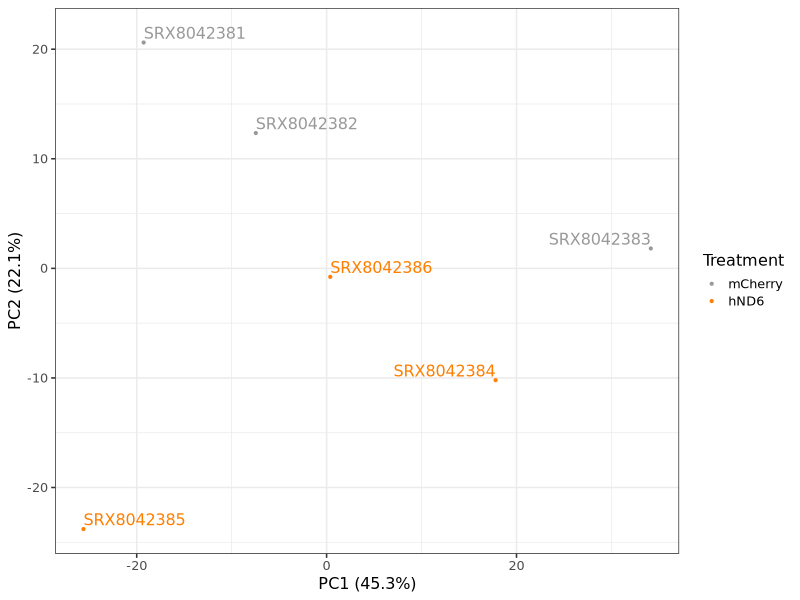

In [3]:
from pathlib import Path
from IPython.display import Image, display

pca_plot = next(Path("results/plots/exploratory").rglob("pca2d.png"))
display(Image(filename=str(pca_plot)))

The PCA plot summarizes the overall variation between samples.

treatment_mCherry_hND6__SRP254919


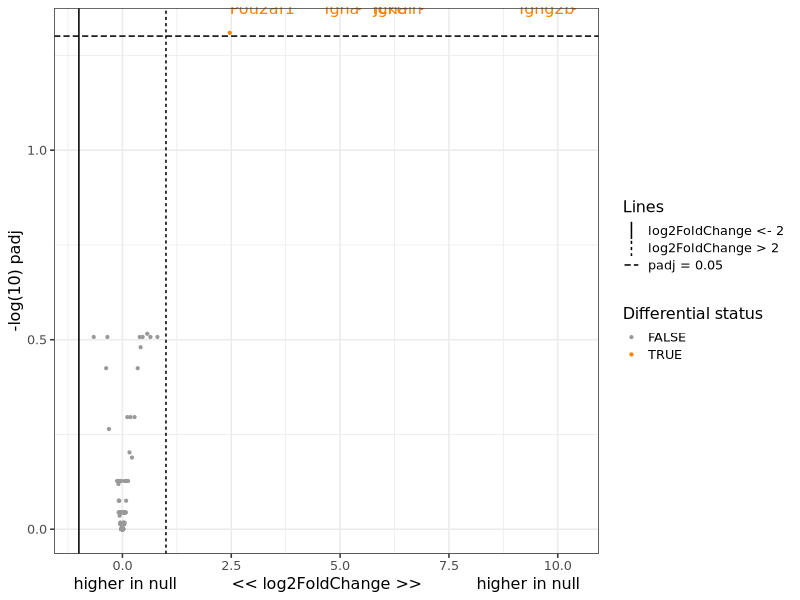

treatment_mCherry_hND6_sample_number_SRP254919


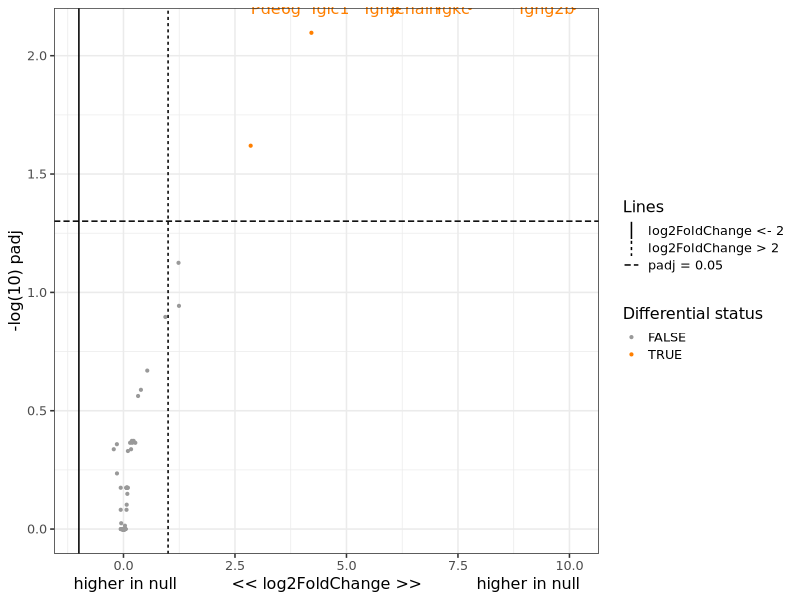

In [4]:
volcano_plots = sorted(Path("results/plots/differential").rglob("volcano.png"))

for plot in volcano_plots:
    print(plot.parent.parent.name)
    display(Image(filename=str(plot)))

The volcano plots show the effect size and statistical significance for the two contrasts. Only a small number of genes, shown in orange, pass the differential-abundance thresholds.

Both analyses compare hND6 with mCherry. The first does not include a blocking factor, whereas the second includes sample_number to account for differences between the numbered sample blocks. This adjustment can change the estimated treatment effects and adjusted p-values, leading to differences between the volcano plots.